# Нейронная сеть прямого распространения (Feedforward NN) — Предсказание цен авиабилетов

**Нейронная сеть прямого распространения (Feedforward Neural Network, FNN)** — базовая архитектура 
нейронных сетей, в которой информация движется строго в одном направлении: от входного слоя через 
скрытые слои к выходному. Каждый нейрон вычисляет взвешенную сумму входов, применяет нелинейную 
функцию активации и передаёт результат дальше. Обучение происходит методом обратного распространения 
ошибки с использованием градиентного спуска для минимизации функции потерь. В задаче регрессии 
выходной слой содержит один нейрон без функции активации, а в качестве функции потерь используется 
MSE (среднеквадратичная ошибка). FNN способны аппроксимировать произвольные нелинейные зависимости, 
что делает их мощным инструментом для предсказания непрерывных величин.

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Устройство: {device}")
print("Все библиотеки импортированы!")

PyTorch: 2.10.0+cu128
Устройство: cuda
Все библиотеки импортированы!


## Описание датасета

https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction

### Краткое описание

**Flight Price Prediction** — датасет, содержащий информацию о стоимости авиабилетов на внутренние 
рейсы в Индии. Данные собраны с платформы Easemytrip и включают около 300 000 записей с различными 
характеристиками перелётов.

### Признаки датасета:

| Признак | Описание |
|---------|----------|
| **airline** | Авиакомпания (6 компаний: Vistara, Air India, IndiGo, GO_FIRST, AirAsia, SpiceJet) |
| **flight** | Код рейса |
| **source_city** | Город вылета (6 городов) |
| **departure_time** | Время вылета (Early_Morning, Morning, Afternoon, Evening, Night, Late_Night) |
| **stops** | Количество пересадок (zero, one, two_or_more) |
| **arrival_time** | Время прилёта (аналогично departure_time) |
| **destination_city** | Город прилёта (6 городов) |
| **class** | Класс обслуживания (Economy, Business) |
| **duration** | Продолжительность перелёта (часы) |
| **days_left** | Количество дней до вылета от даты бронирования |
| **price** | **Целевая переменная** — стоимость билета (индийские рупии) |

In [2]:
df = pd.read_csv('/kaggle/input/datasets/shubhambathwal/flight-price-prediction/Clean_Dataset.csv')

print("=" * 60)
print("ОБЩАЯ ИНФОРМАЦИЯ")
print("=" * 60)
print(f"\nРазмер: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
print(f"Столбцы: {list(df.columns)}")

print("\n" + "=" * 60)
print("ПЕРВЫЕ 10 СТРОК")
print("=" * 60)
df.head(10)

ОБЩАЯ ИНФОРМАЦИЯ

Размер: 300,153 строк, 12 столбцов
Столбцы: ['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']

ПЕРВЫЕ 10 СТРОК


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


In [3]:
print("=" * 60)
print("ТИПЫ ДАННЫХ И ПРОПУСКИ")
print("=" * 60)
print(df.dtypes)
print(f"\nПропуски: {df.isnull().sum().sum()}")
print(f"Дубликаты: {df.duplicated().sum()}")

print("\n" + "=" * 60)
print("СТАТИСТИКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (price)")
print("=" * 60)
print(df['price'].describe().round(0))

ТИПЫ ДАННЫХ И ПРОПУСКИ
Unnamed: 0            int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

Пропуски: 0
Дубликаты: 0

СТАТИСТИКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (price)
count    300153.0
mean      20890.0
std       22698.0
min        1105.0
25%        4783.0
50%        7425.0
75%       42521.0
max      123071.0
Name: price, dtype: float64


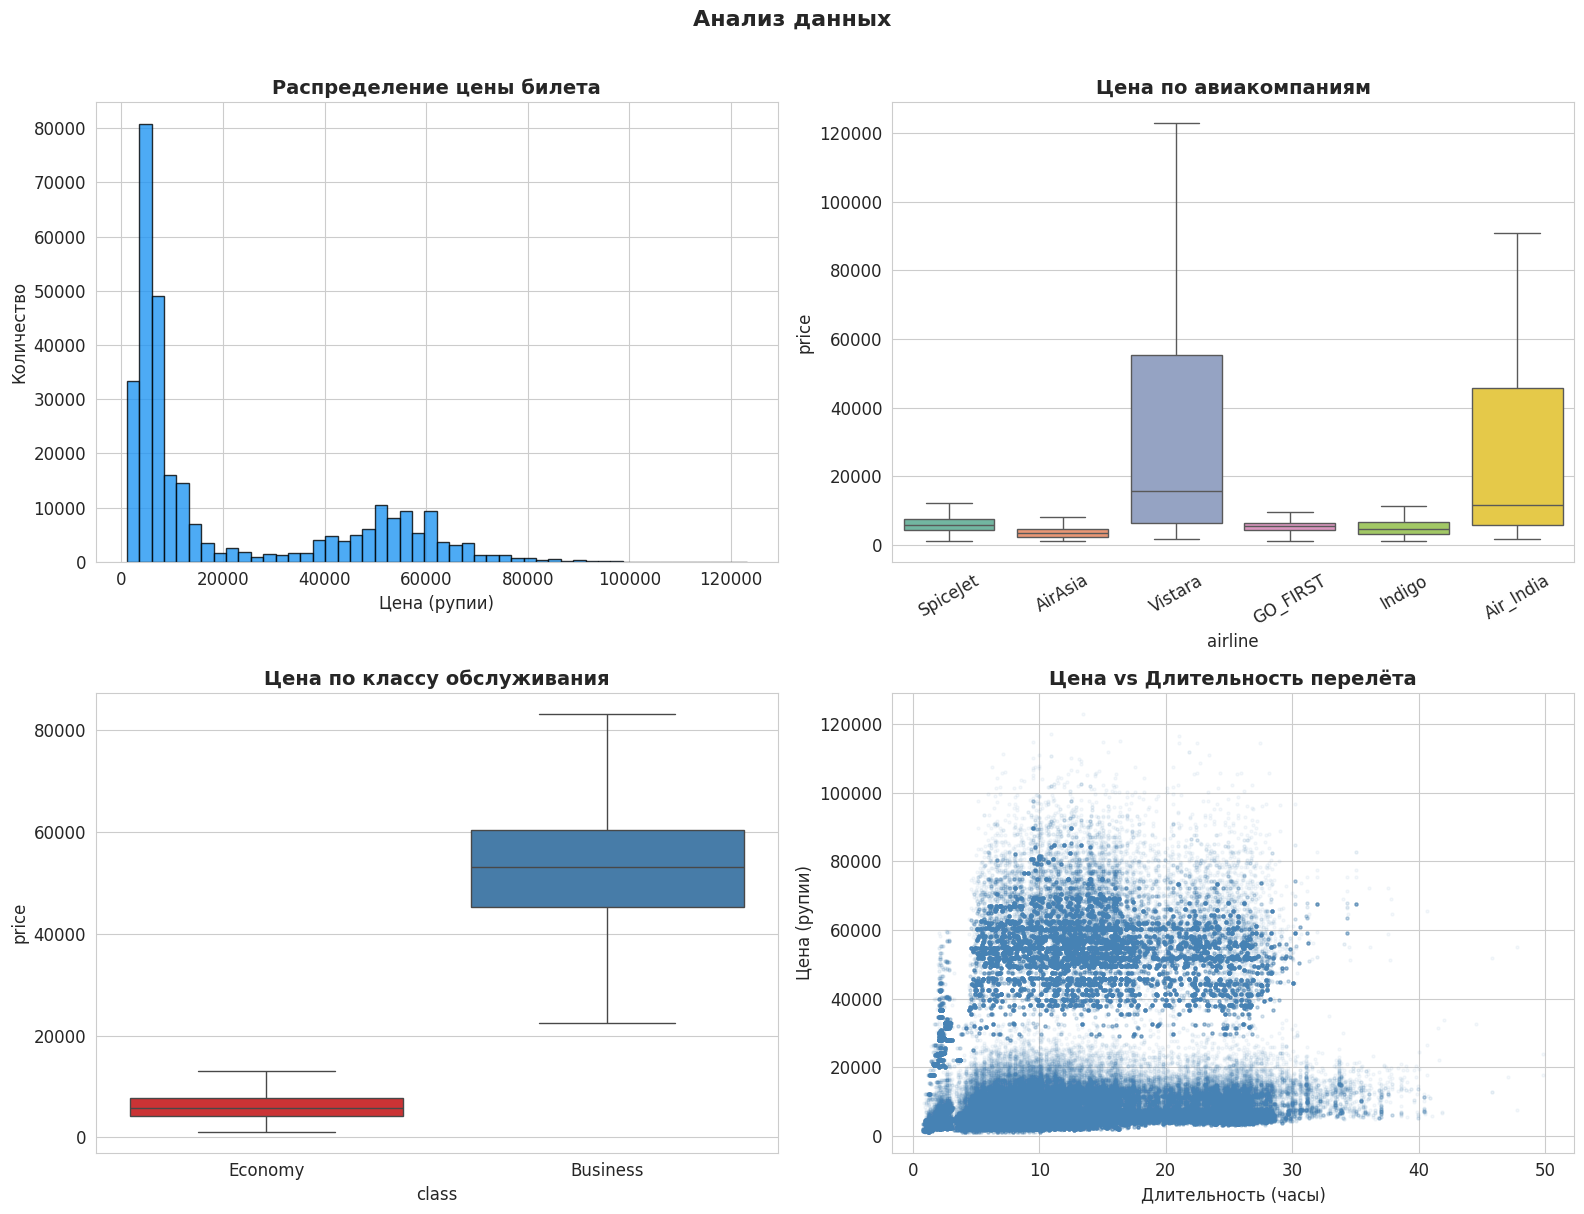

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Распределение цены
axes[0, 0].hist(df['price'], bins=50, color='#2196F3', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Распределение цены билета', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Цена (рупии)')
axes[0, 0].set_ylabel('Количество')

# Цена по авиакомпаниям
sns.boxplot(data=df, x='airline', y='price', ax=axes[0, 1],
            palette='Set2', showfliers=False)
axes[0, 1].set_title('Цена по авиакомпаниям', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=30)

# Цена по классу
sns.boxplot(data=df, x='class', y='price', ax=axes[1, 0],
            palette='Set1', showfliers=False)
axes[1, 0].set_title('Цена по классу обслуживания', fontsize=14, fontweight='bold')

# Цена vs длительность
axes[1, 1].scatter(df['duration'], df['price'], alpha=0.05, s=5, color='steelblue')
axes[1, 1].set_title('Цена vs Длительность перелёта', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Длительность (часы)')
axes[1, 1].set_ylabel('Цена (рупии)')

plt.suptitle('Анализ данных', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Предварительная обработка датасета

In [5]:
df_clean = df.copy()

# Удаляем столбец Unnamed: 0 если есть
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])

# Удаляем код рейса (слишком много уникальных значений)
if 'flight' in df_clean.columns:
    df_clean = df_clean.drop(columns=['flight'])

print(f"Столбцы: {list(df_clean.columns)}")
print(f"Размер: {df_clean.shape}")

Столбцы: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']
Размер: (300153, 10)


In [6]:
# Кодирование категориальных признаков (LabelEncoder — не раздувает размерность)
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные: {cat_cols}")

encoders = {}
for c in cat_cols:
    enc = LabelEncoder()
    df_clean[c] = enc.fit_transform(df_clean[c])
    encoders[c] = enc
    print(f"  {c}: {len(enc.classes_)} категорий -> {list(enc.classes_)}")

print(f"\nПропуски: {df_clean.isnull().sum().sum()}")
df_clean = df_clean.dropna()
print(f"Размер: {df_clean.shape}")

Категориальные: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
  airline: 6 категорий -> ['AirAsia', 'Air_India', 'GO_FIRST', 'Indigo', 'SpiceJet', 'Vistara']
  source_city: 6 категорий -> ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']
  departure_time: 6 категорий -> ['Afternoon', 'Early_Morning', 'Evening', 'Late_Night', 'Morning', 'Night']
  stops: 3 категорий -> ['one', 'two_or_more', 'zero']
  arrival_time: 6 категорий -> ['Afternoon', 'Early_Morning', 'Evening', 'Late_Night', 'Morning', 'Night']
  destination_city: 6 категорий -> ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']
  class: 2 категорий -> ['Business', 'Economy']

Пропуски: 0
Размер: (300153, 10)


In [7]:
# Целевая переменная
target_col = 'price'

X = df_clean.drop(columns=[target_col]).values.astype(np.float32)
y = df_clean[target_col].values.astype(np.float32)
feature_names = [c for c in df_clean.columns if c != target_col]

print(f"Признаки ({len(feature_names)}): {feature_names}")
print(f"X: {X.shape}, y: {y.shape}")
print(f"\nЦена: min={y.min():.0f}, max={y.max():.0f}, mean={y.mean():.0f}, median={np.median(y):.0f}")

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")

# Масштабирование признаков
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

# Масштабирование целевой переменной (ускоряет обучение)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print("Масштабирование выполнено!")

Признаки (9): ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left']
X: (300153, 9), y: (300153,)

Цена: min=1105, max=123071, mean=20890, median=7425

X_train: (240122, 9), X_test: (60031, 9)
Масштабирование выполнено!


## Тепловая карта корреляций (Heatmap)

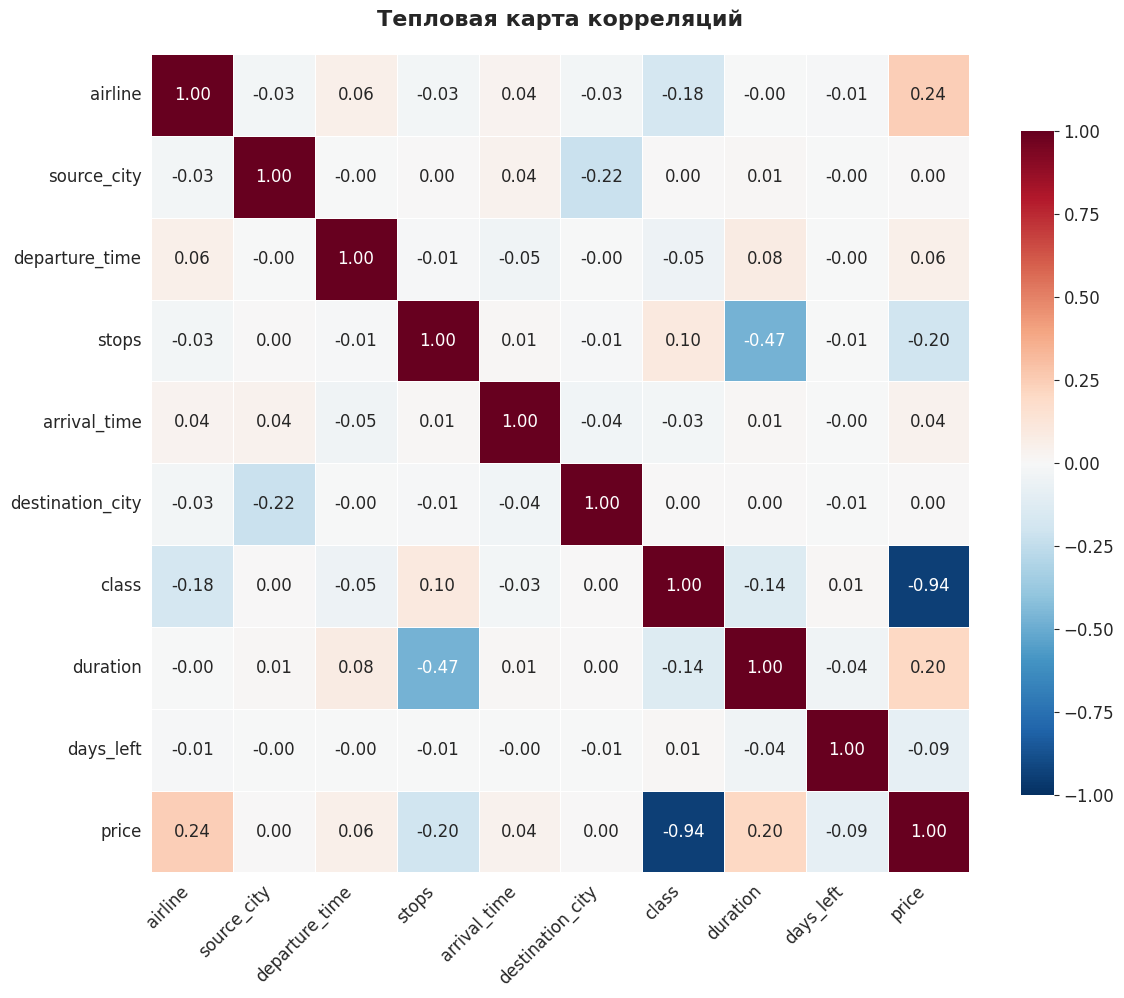

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))

corr = df_clean.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
ax.set_title('Тепловая карта корреляций', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕНОЙ
  class                -0.9379 (-) ████████████████████████████
  airline              +0.2434 (+) ███████
  duration             +0.2042 (+) ██████
  stops                -0.2026 (-) ██████
  days_left            -0.0919 (-) ██
  departure_time       +0.0583 (+) █
  arrival_time         +0.0420 (+) █
  destination_city     +0.0048 (+) 
  source_city          +0.0046 (+) 


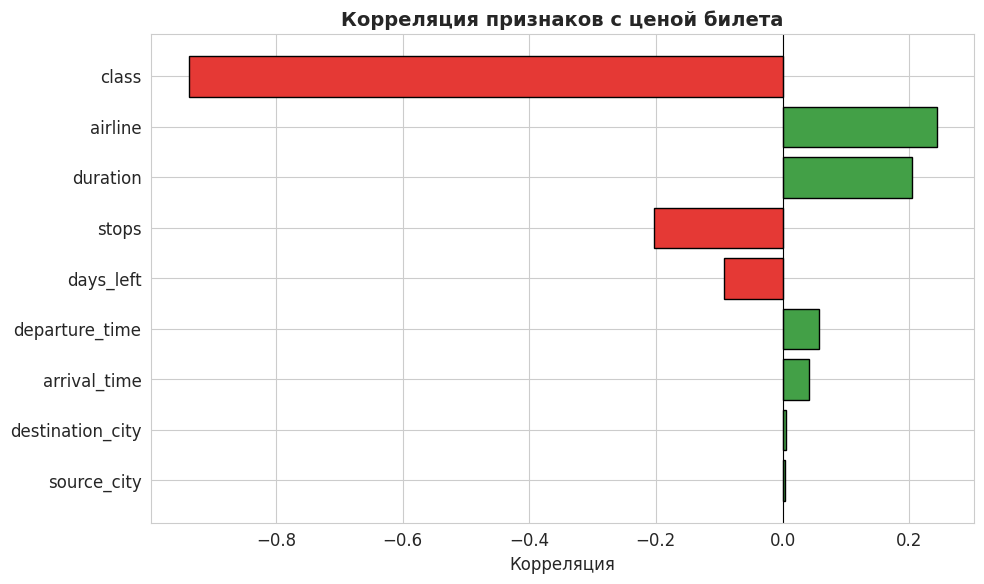

In [9]:
# Корреляция с целевой переменной
target_corr = corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)

print("=" * 60)
print("КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕНОЙ")
print("=" * 60)
for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:<20} {val:+.4f} ({sign}) {bar}")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#43A047' if v > 0 else '#E53935' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
ax.set_title('Корреляция признаков с ценой билета', fontsize=14, fontweight='bold')
ax.set_xlabel('Корреляция')
ax.axvline(x=0, color='black', lw=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Построение и обучение нейронной сети

In [10]:
# Подготовка данных для PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

BATCH_SIZE = 512
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

n_features = X_train.shape[1]
print(f"Признаков: {n_features}")
print(f"Train: {len(y_train):,}, Test: {len(y_test):,}")

Признаков: 9
Train: 240,122, Test: 60,031


In [11]:
class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super(RegressionNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # Один выход — цена
        )

    def forward(self, x):
        return self.network(x)

model = RegressionNN(n_features).to(device)

print("=" * 60)
print("АРХИТЕКТУРА НЕЙРОННОЙ СЕТИ")
print("=" * 60)
print(model)
print(f"\nПараметров: {sum(p.numel() for p in model.parameters()):,}")

АРХИТЕКТУРА НЕЙРОННОЙ СЕТИ
RegressionNN(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
  )
)

Параметров: 46,721


In [13]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-6)

EPOCHS = 100
PATIENCE = 20

train_losses, test_losses = [], []
best_test_loss = float('inf')
best_epoch = 0
best_model_state = None
epochs_no_improve = 0

print("=" * 60)
print("ОБУЧЕНИЕ НЕЙРОННОЙ СЕТИ")
print("=" * 60)

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # --- Eval ---
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)

    test_loss = running_loss / len(test_loader.dataset)
    test_losses.append(test_loss)

    scheduler.step()

    # Early stopping
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch + 1
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"  Эпоха {epoch+1:3d}/{EPOCHS} | "
              f"Train MSE: {train_loss:.6f} | Test MSE: {test_loss:.6f} | "
              f"LR: {lr:.6f}")

    if epochs_no_improve >= PATIENCE:
        print(f"\n  Early stopping (эпоха {epoch+1})")
        break

model.load_state_dict(best_model_state)
print(f"\nЛучший Test MSE: {best_test_loss:.6f} (эпоха {best_epoch})")

ОБУЧЕНИЕ НЕЙРОННОЙ СЕТИ
  Эпоха   1/100 | Train MSE: 0.039513 | Test MSE: 0.036807 | LR: 0.001000
  Эпоха  10/100 | Train MSE: 0.039173 | Test MSE: 0.036320 | LR: 0.000962
  Эпоха  20/100 | Train MSE: 0.038588 | Test MSE: 0.035449 | LR: 0.000854
  Эпоха  30/100 | Train MSE: 0.037787 | Test MSE: 0.033635 | LR: 0.000692
  Эпоха  40/100 | Train MSE: 0.036723 | Test MSE: 0.032720 | LR: 0.000501
  Эпоха  50/100 | Train MSE: 0.035261 | Test MSE: 0.031462 | LR: 0.000309
  Эпоха  60/100 | Train MSE: 0.034223 | Test MSE: 0.030300 | LR: 0.000147
  Эпоха  70/100 | Train MSE: 0.033006 | Test MSE: 0.029477 | LR: 0.000039
  Эпоха  80/100 | Train MSE: 0.032637 | Test MSE: 0.029319 | LR: 0.000001
  Эпоха  90/100 | Train MSE: 0.032736 | Test MSE: 0.029453 | LR: 0.000039
  Эпоха 100/100 | Train MSE: 0.033449 | Test MSE: 0.029684 | LR: 0.000147

Лучший Test MSE: 0.029237 (эпоха 86)


## Прогнозы модели

In [14]:
model.eval()
all_preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        all_preds.extend(outputs.cpu().numpy().flatten())

# Обратное масштабирование
y_pred_scaled = np.array(all_preds)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print("=" * 60)
print("ПРОГНОЗЫ МОДЕЛИ")
print("=" * 60)

comparison = pd.DataFrame({
    'Реальная цена': y_test[:20].astype(int),
    'Предсказание': y_pred[:20].astype(int),
    'Ошибка': (y_pred[:20] - y_test[:20]).astype(int),
    'Ошибка (%)': ((y_pred[:20] - y_test[:20]) / y_test[:20] * 100).round(1)
})
print("\nПервые 20 прогнозов:")
print(comparison.to_string(index=False))

print(f"\nСредняя реальная цена:  {y_test.mean():,.0f} рупий")
print(f"Среднее предсказание:   {y_pred.mean():,.0f} рупий")

ПРОГНОЗЫ МОДЕЛИ

Первые 20 прогнозов:
 Реальная цена  Предсказание  Ошибка  Ошибка (%)
          7366          5394   -1971  -26.799999
         64831         64727    -103   -0.200000
          6195          7129     934   15.100000
         60160         56968   -3191   -5.300000
          6578          6437    -140   -2.100000
          4555          8244    3689   81.000000
         23838         23662    -175   -0.700000
          3860          4278     418   10.800000
         32230         49469   17239   53.500000
         76841         70759   -6081   -7.900000
         38099         49671   11572   30.400000
         60508         60233    -274   -0.500000
          2477          3489    1012   40.900002
          7220          6496    -723  -10.000000
         32859         33660     801    2.400000
         20684         21084     400    1.900000
          7212          6668    -543   -7.500000
          7762          4108   -3653  -47.099998
         22140         22869   

## Графики и метрики регрессии

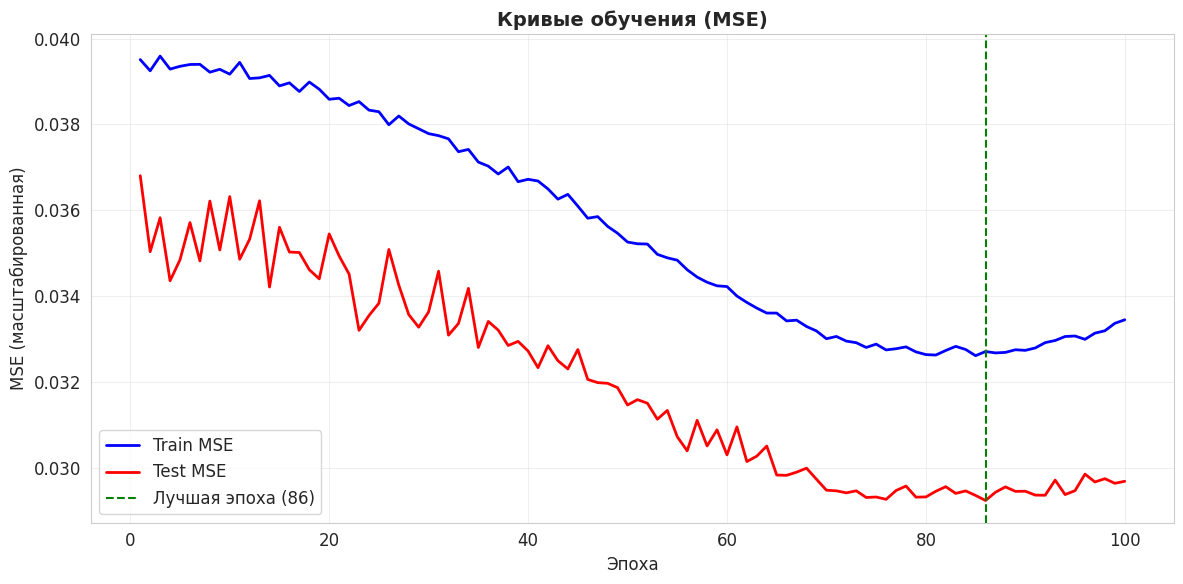

In [15]:
# Кривые обучения
actual_epochs = len(train_losses)
epochs_range = range(1, actual_epochs + 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(epochs_range, train_losses, 'b-', lw=2, label='Train MSE')
ax.plot(epochs_range, test_losses, 'r-', lw=2, label='Test MSE')
ax.axvline(x=best_epoch, color='green', linestyle='--', lw=1.5,
           label=f'Лучшая эпоха ({best_epoch})')
ax.set_title('Кривые обучения (MSE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE (масштабированная)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Метрики регрессии
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("=" * 60)
print("МЕТРИКИ РЕГРЕССИИ")
print("=" * 60)
print(f"\n  MAE  (средняя абс. ошибка):    {mae:,.0f} рупий")
print(f"  RMSE (корень средней кв.):      {rmse:,.0f} рупий")
print(f"  MSE  (средняя квадратичная):    {mse:,.0f}")
print(f"  R²   (коэф. детерминации):      {r2:.4f}")
print(f"  MAPE (средняя % ошибка):        {mape:.2f}%")
print(f"\n  Средняя цена в тесте:           {y_test.mean():,.0f} рупий")
print(f"  MAE как % от средней цены:      {mae/y_test.mean()*100:.2f}%")

МЕТРИКИ РЕГРЕССИИ

  MAE  (средняя абс. ошибка):    2,210 рупий
  RMSE (корень средней кв.):      3,881 рупий
  MSE  (средняя квадратичная):    15,060,124
  R²   (коэф. детерминации):      0.9708
  MAPE (средняя % ошибка):        18.24%

  Средняя цена в тесте:           20,894 рупий
  MAE как % от средней цены:      10.58%


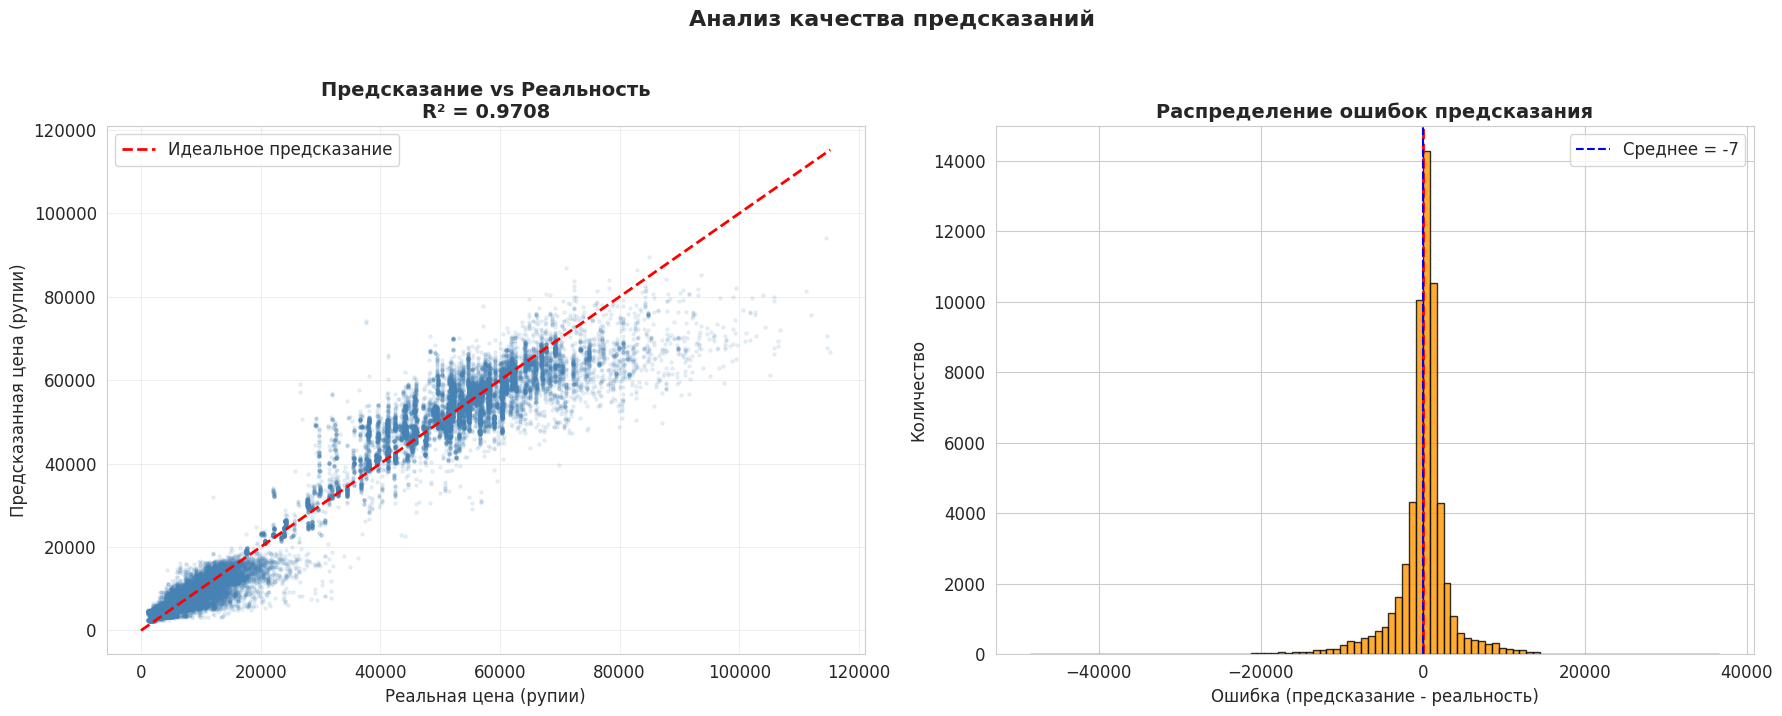

In [17]:
# Предсказания vs Реальность
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter
axes[0].scatter(y_test, y_pred, alpha=0.1, s=5, color='steelblue')
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Идеальное предсказание')
axes[0].set_title(f'Предсказание vs Реальность\nR² = {r2:.4f}',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Реальная цена (рупии)')
axes[0].set_ylabel('Предсказанная цена (рупии)')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Распределение ошибок
errors = y_pred - y_test
axes[1].hist(errors, bins=100, color='#FF9800', edgecolor='black', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].axvline(x=errors.mean(), color='blue', linestyle='--', lw=1.5,
                label=f'Среднее = {errors.mean():,.0f}')
axes[1].set_title('Распределение ошибок предсказания', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ошибка (предсказание - реальность)')
axes[1].set_ylabel('Количество')
axes[1].legend(fontsize=12)

plt.suptitle('Анализ качества предсказаний', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ОШИБКИ ПО ДИАПАЗОНАМ ЦЕН
                   MAE     MedianAE     MAPE %  Медианная % ош.  Кол-во
price_bin                                                              
0-5K       1089.599976   956.200012  34.700001             27.1   16287
5K-10K      978.799988   646.000000  14.200000             10.1   18482
10K-20K    2177.500000  1482.199951  16.200001             11.8    6321
20K-40K    4463.799805  2361.699951  14.700000              8.1    3071
40K-60K    3477.699951  2404.899902   6.900000              4.7   10783
60K+       6259.100098  4018.199951   8.700000              6.3    5087


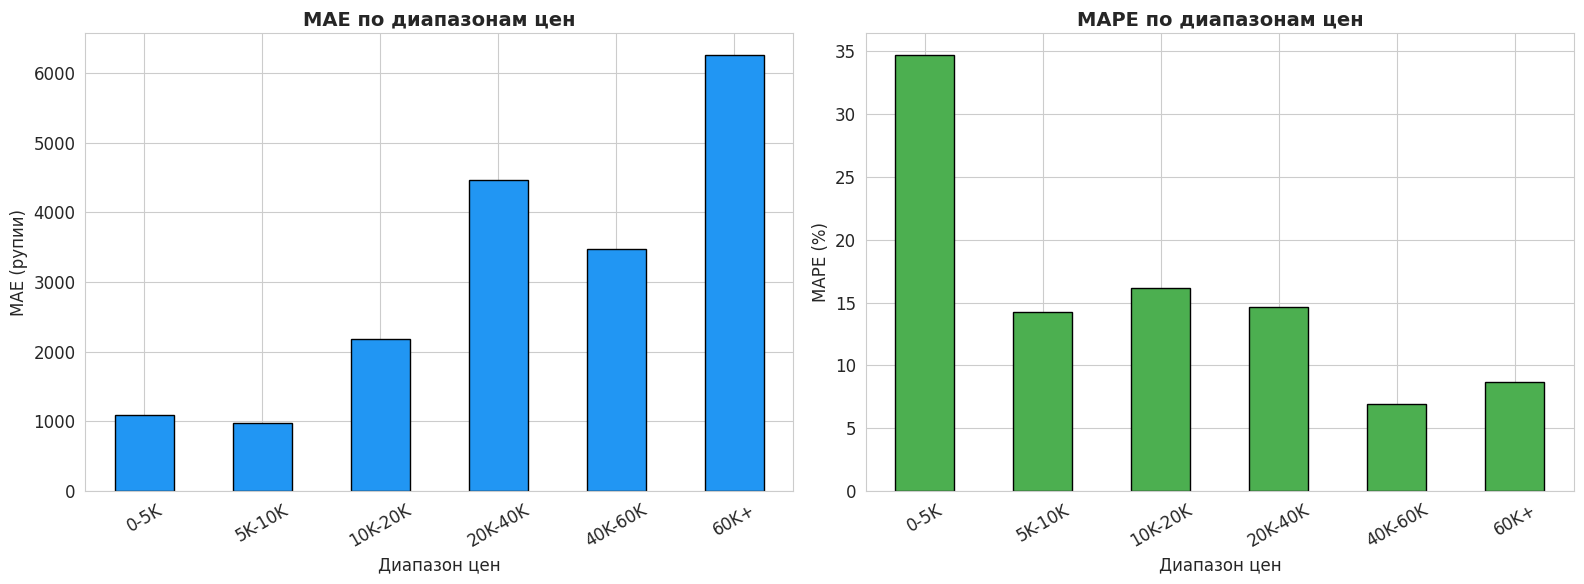

In [18]:
# Ошибки по диапазонам цен
bins = [0, 5000, 10000, 20000, 40000, 60000, np.inf]
labels_bins = ['0-5K', '5K-10K', '10K-20K', '20K-40K', '40K-60K', '60K+']

df_errors = pd.DataFrame({
    'real': y_test,
    'pred': y_pred,
    'error': np.abs(y_pred - y_test),
    'pct_error': np.abs(y_pred - y_test) / y_test * 100
})
df_errors['price_bin'] = pd.cut(df_errors['real'], bins=bins, labels=labels_bins)

print("=" * 60)
print("ОШИБКИ ПО ДИАПАЗОНАМ ЦЕН")
print("=" * 60)

bin_stats = df_errors.groupby('price_bin', observed=True).agg({
    'error': ['mean', 'median'],
    'pct_error': ['mean', 'median'],
    'real': 'count'
}).round(1)
bin_stats.columns = ['MAE', 'MedianAE', 'MAPE %', 'Медианная % ош.', 'Кол-во']
print(bin_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bin_mae = df_errors.groupby('price_bin', observed=True)['error'].mean()
bin_mae.plot(kind='bar', color='#2196F3', edgecolor='black', ax=axes[0])
axes[0].set_title('MAE по диапазонам цен', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Диапазон цен')
axes[0].set_ylabel('MAE (рупии)')
axes[0].tick_params(axis='x', rotation=30)

bin_mape = df_errors.groupby('price_bin', observed=True)['pct_error'].mean()
bin_mape.plot(kind='bar', color='#4CAF50', edgecolor='black', ax=axes[1])
axes[1].set_title('MAPE по диапазонам цен', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Диапазон цен')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()